In [1]:
# Goal:
# Explore booking patterns in Bethpage tee time reservations
# to understand demand patterns and identify capacity bottlenecks.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_parquet("../data/cleaned/bethpage_bookings_clean.parquet")
df = df[df["invalid_tee_time"] == False]
display(df.head())
display(df.size)
display(df.columns)




,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
0,2021-03-14 07:51:00,2021-03-07 19:00:00,played,NaT,weekend,morning,2,Blue,9,124.0,False,False
1,2021-03-14 07:51:00,2021-03-13 21:35:00,played,NaT,weekend,morning,1,Blue,9,31.0,False,False
2,2021-03-14 08:00:00,2021-03-13 15:32:00,played,NaT,weekend,morning,2,Blue,9,62.0,False,False
3,2021-03-14 08:27:00,2021-03-13 11:19:00,played,NaT,weekend,morning,4,Blue,9,124.0,False,False
4,2021-03-14 08:36:00,2021-03-13 17:42:00,played,NaT,weekend,morning,3,Blue,9,93.0,False,False


7391592

Index(['tee_time', 'booking_time', 'status_text', 'date_cancelled',
       'time_of_week', 'time_of_day', 'player_count_final', 'course',
       'round_length', 'cost_per_group', 'invalid_cancellation',
       'invalid_tee_time'],
      dtype='object')

In [2]:
#basic data review & integrity checks
display(df.info())
display(df.describe())
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 615966 entries, 0 to 616012
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tee_time              615966 non-null  datetime64[ns]
 1   booking_time          615966 non-null  datetime64[ns]
 2   status_text           615966 non-null  category      
 3   date_cancelled        308206 non-null  datetime64[ns]
 4   time_of_week          615966 non-null  category      
 5   time_of_day           615966 non-null  category      
 6   player_count_final    615966 non-null  int64         
 7   course                615966 non-null  object        
 8   round_length          615966 non-null  int64         
 9   cost_per_group        599826 non-null  float64       
 10  invalid_cancellation  615966 non-null  bool          
 11  invalid_tee_time      615966 non-null  bool          
dtypes: bool(2), category(3), datetime64[ns](3), float64(1), int64(2

None

,tee_time,booking_time,date_cancelled,player_count_final,round_length,cost_per_group
count,615966,615966,308206,615966.000000,615966.000000,599826.000000
mean,2023-07-01 23:48:48.636969728,2023-06-28 16:14:54.106233856,2023-08-13 07:08:35.910287360,2.620776,15.286613,121.421936
min,2021-03-14 07:51:00,2021-03-07 19:00:00,2021-03-11 14:44:21,1.000000,9.000000,0.000000
25%,2022-07-24 12:00:00,2022-07-21 14:30:15,2022-09-29 11:59:30,1.000000,9.000000,53.000000
50%,2023-07-09 06:03:00,2023-07-05 19:00:00,2023-07-28 12:55:30,2.000000,18.000000,106.000000
75%,2024-06-16 14:36:00,2024-06-13 14:14:45,2024-05-28 19:28:46,4.000000,18.000000,172.000000
max,2025-10-21 14:00:00,2025-10-15 14:44:00,2025-10-15 13:40:01,4.000000,18.000000,660.000000
std,NaN,NaN,NaN,1.287343,4.130138,80.428146


tee_time                     0
booking_time                 0
status_text                  0
date_cancelled          307760
time_of_week                 0
time_of_day                  0
player_count_final           0
course                       0
round_length                 0
cost_per_group           16140
invalid_cancellation         0
invalid_tee_time             0
dtype: int64

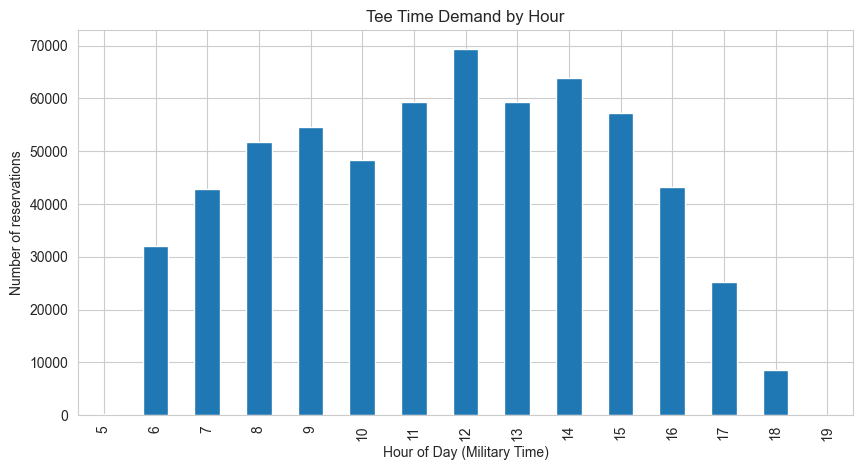

In [3]:
#demand by hour
hourly_demand = df.groupby(df["tee_time"].dt.hour).size()

hourly_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Hour")
plt.xlabel("Hour of Day (Military Time)")
plt.ylabel("Number of reservations")
plt.show()

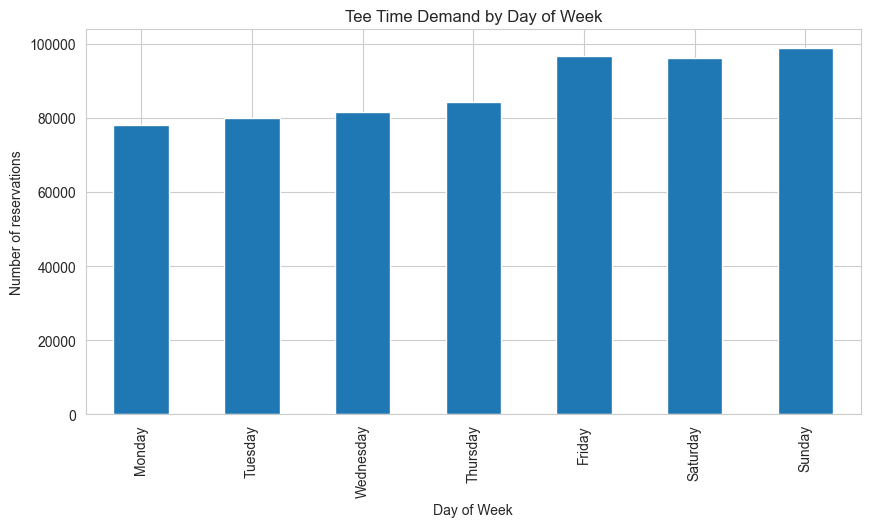

In [4]:
#demand by day of week 
DOW_demand = df.groupby(df["tee_time"].dt.day_name()).size()
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
DOW_demand = DOW_demand.reindex(day_order)

DOW_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of reservations")
plt.show()


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
tee_time,,,,,,,
5,57,37,33,23,50,37,28
6,5558,4898,3904,4617,4730,4176,4184
7,6830,6082,4867,5971,6170,6348,6536
8,7569,6874,6312,6951,7542,8108,8383
9,7764,6686,7135,7511,7434,8694,9398
10,6492,5807,6598,6453,7721,7381,7843
11,7629,7284,8272,8369,9564,9264,8993
12,9067,9086,9444,9527,10669,10669,10963
13,6786,8466,8817,8747,9172,8341,8994


Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object')

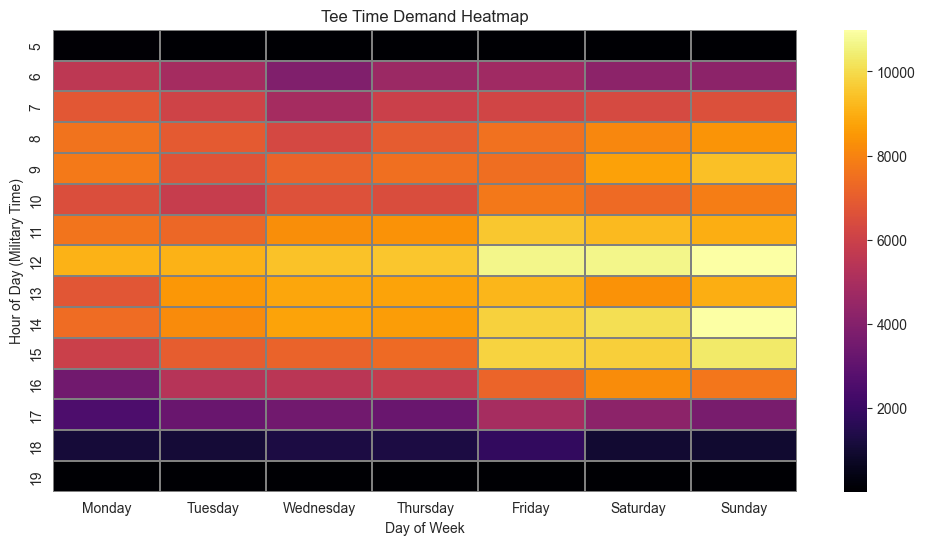

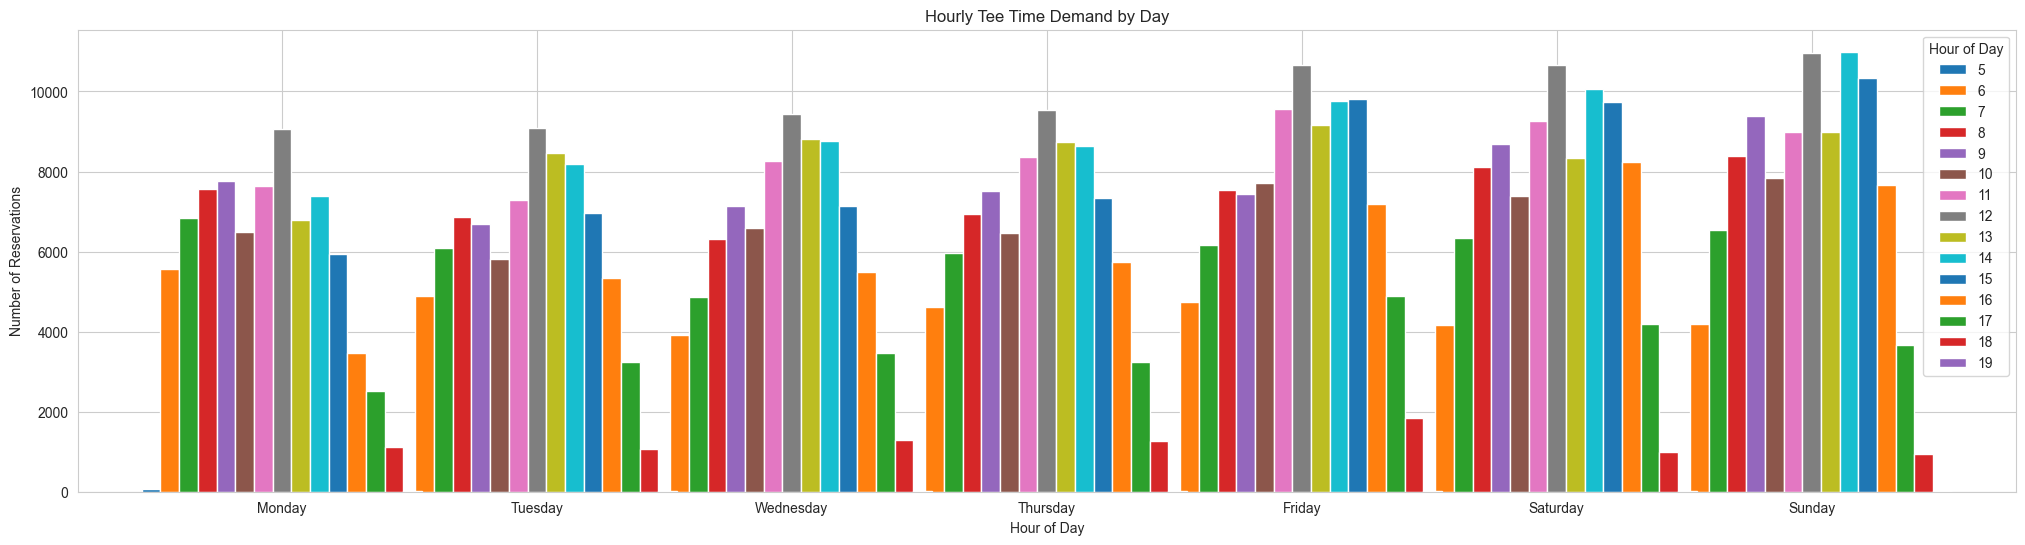

In [5]:
#DOW vs Hour heatmap
heatmap_data = df.groupby([df["tee_time"].dt.hour,df["tee_time"].dt.dayofweek]).size().unstack()
heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
display(heatmap_data)
display(heatmap_data.columns)

#heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time Demand Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#day by hour bar chart
heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.1)
plt.title("Hourly Tee Time Demand by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=0)
plt.show()

,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
5358,2021-04-16 05:18:00,2021-04-15 18:26:00,unknown,NaT,weekday,morning,4,Yellow,9,172.0,False,False
11572,2021-05-10 05:45:00,2021-05-03 19:30:00,played,NaT,weekday,morning,1,Yellow,9,28.0,False,False
12408,2021-05-13 05:54:00,2021-05-12 21:52:00,played,NaT,weekday,morning,1,Red,18,28.0,False,False
13612,2021-05-16 05:45:00,2021-05-15 22:01:00,played,NaT,weekend,morning,1,Yellow,9,31.0,False,False
14007,2021-05-17 05:45:00,2021-05-16 16:39:00,played,NaT,weekday,morning,1,Red,18,48.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
607872,2025-08-01 05:54:00,2025-07-25 19:03:00,cancelled,2025-08-01 07:09:53,weekday,morning,4,Blue,18,100.0,True,False
608128,2025-08-02 05:54:00,2025-07-26 19:11:00,played,NaT,weekend,morning,1,Yellow,9,NaN,False,False
608384,2025-08-03 05:54:00,2025-07-27 19:00:00,played,NaT,weekend,morning,1,Yellow,9,0.0,False,False
615312,2025-10-13 05:00:00,2025-10-06 19:00:00,cancelled,2025-10-15 09:53:17,weekday,morning,4,Blue,18,172.0,True,False


tee_time
2021    55
2022    46
2023    47
2024    53
2025    64
dtype: int64

tee_time,1,2,3,4,5,6,7,8,9,10,11,12
tee_time,,,,,,,,,,,,
5,8.0,3.0,2.0,6.0,71.0,86.0,57.0,7.0,2.0,3.0,11.0,9.0
6,NaN,NaN,NaN,1883.0,8150.0,9073.0,8464.0,3871.0,626.0,NaN,NaN,NaN
7,NaN,NaN,616.0,7731.0,6809.0,6623.0,6309.0,7397.0,4660.0,2172.0,479.0,8.0
8,2.0,NaN,2614.0,8475.0,5985.0,5388.0,5618.0,4891.0,4970.0,7597.0,6121.0,78.0
9,572.0,699.0,2829.0,6602.0,7488.0,6783.0,6942.0,5693.0,4225.0,4943.0,7022.0,824.0
10,1456.0,1569.0,2385.0,6180.0,5552.0,5492.0,5558.0,4989.0,4751.0,4594.0,4194.0,1575.0
11,1271.0,1231.0,2686.0,7446.0,7443.0,6851.0,6599.0,5977.0,5335.0,6250.0,6706.0,1580.0
12,1724.0,1767.0,3218.0,8377.0,8427.0,7744.0,7681.0,7406.0,6362.0,7222.0,7202.0,2295.0
13,1100.0,1875.0,2876.0,6613.0,7527.0,6984.0,7028.0,6226.0,5362.0,7087.0,5331.0,1314.0


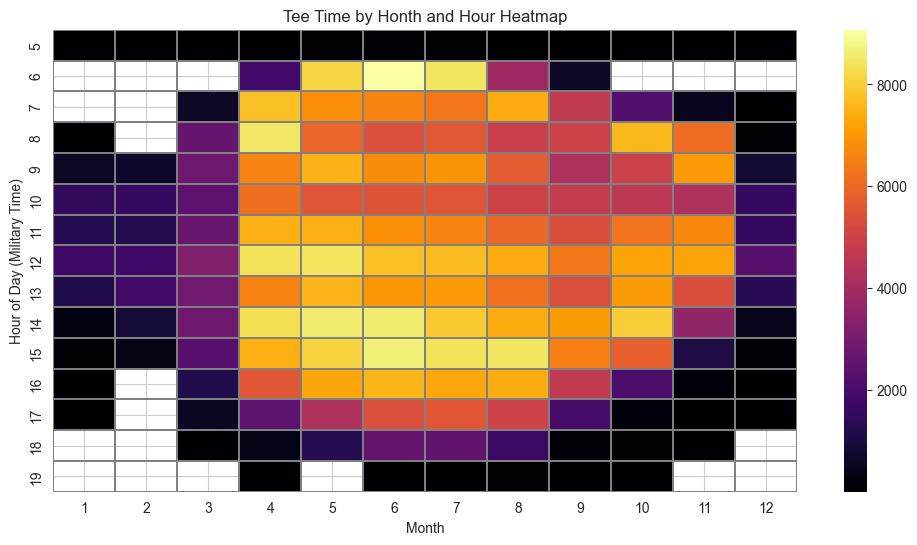

In [6]:
#check odd lack of 5am hour tee times
five_am_res = df[df["tee_time"].dt.hour == 5]
display(five_am_res)
display(five_am_res.groupby(five_am_res["tee_time"].dt.year).size())
#5am times do exist they are just relatively rare, likely due to not being available year round (dst, short spring and fall days)
#also likely undesireable to NYC residents as it takes over an hour to reach the course by car or train

#heatmap of month/hour to confirm daylight restriction theory
early_tee_time_heatmap_data = df.groupby([df["tee_time"].dt.hour,df['tee_time'].dt.month]).size().unstack()
display(early_tee_time_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(early_tee_time_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time by Honth and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

tee_time,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
tee_time,,,,,,,,,,,,
6.0,NaN,NaN,NaN,1883.0,8150.0,9073.0,8464.0,3871.0,626.0,NaN,NaN,NaN
7.0,NaN,NaN,616.0,7731.0,6809.0,6623.0,6309.0,7397.0,4660.0,2172.0,479.0,8.0
8.0,2.0,NaN,2614.0,8475.0,5985.0,5388.0,5618.0,4891.0,4970.0,7597.0,6121.0,78.0
9.0,572.0,699.0,2829.0,6602.0,7488.0,6783.0,6942.0,5693.0,4225.0,4943.0,7022.0,824.0
10.0,1456.0,1569.0,2385.0,6180.0,5552.0,5492.0,5558.0,4989.0,4751.0,4594.0,4194.0,1575.0
11.0,1271.0,1231.0,2686.0,7446.0,7443.0,6851.0,6599.0,5977.0,5335.0,6250.0,6706.0,1580.0
12.0,1724.0,1767.0,3218.0,8377.0,8427.0,7744.0,7681.0,7406.0,6362.0,7222.0,7202.0,2295.0
13.0,1100.0,1875.0,2876.0,6613.0,7527.0,6984.0,7028.0,6226.0,5362.0,7087.0,5331.0,1314.0
14.0,274.0,905.0,2827.0,8317.0,8542.0,8549.0,7905.0,7395.0,7073.0,7983.0,3545.0,465.0


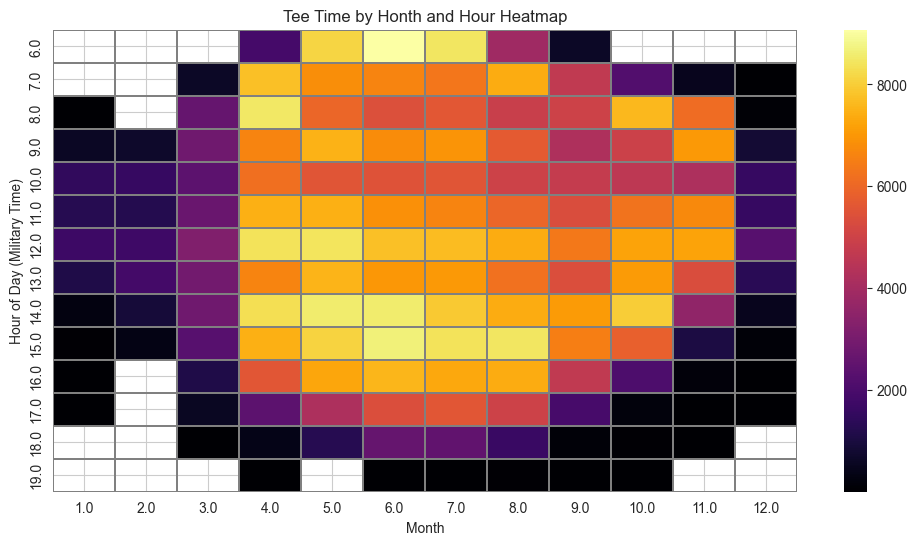

In [7]:
#remove 265 5am tee times as many seem to be data errors. Not possible most of the year when the sun is not up betwen 5am and 6am
df2 = df[df["tee_time"].dt.hour != 5].copy()

#updated heatmap of month/hour to confirm daylight restriction theory
early_tee_time_heatmap_data = df.groupby([df2["tee_time"].dt.hour,df2['tee_time'].dt.month]).size().unstack()
display(early_tee_time_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(early_tee_time_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time by Honth and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

In [8]:
#investigate invalid_cancellation rows to determine if they are biasing demand analysis
df["invalid_cancellation"].value_counts(normalize=True)

#small proportion of data makes True rows OK to include. Will remove from cancellation analysis to avoid NAT errors


invalid_cancellation
False    0.995488
True     0.004512
Name: proportion, dtype: float64

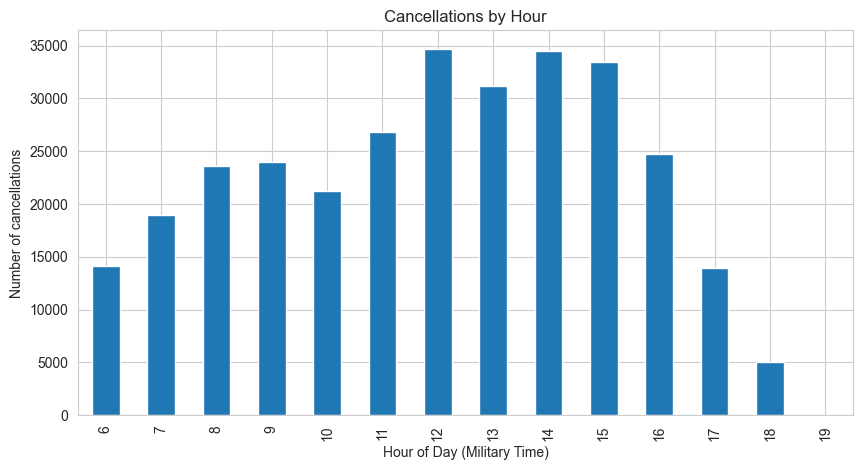

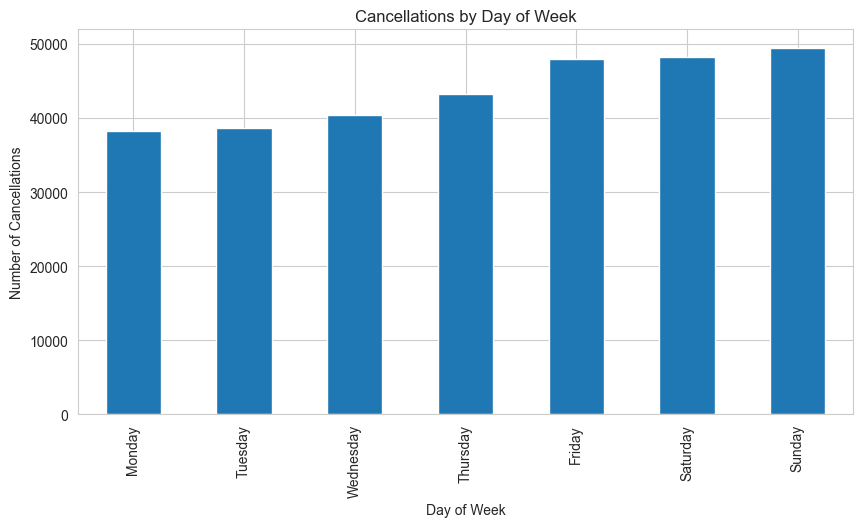

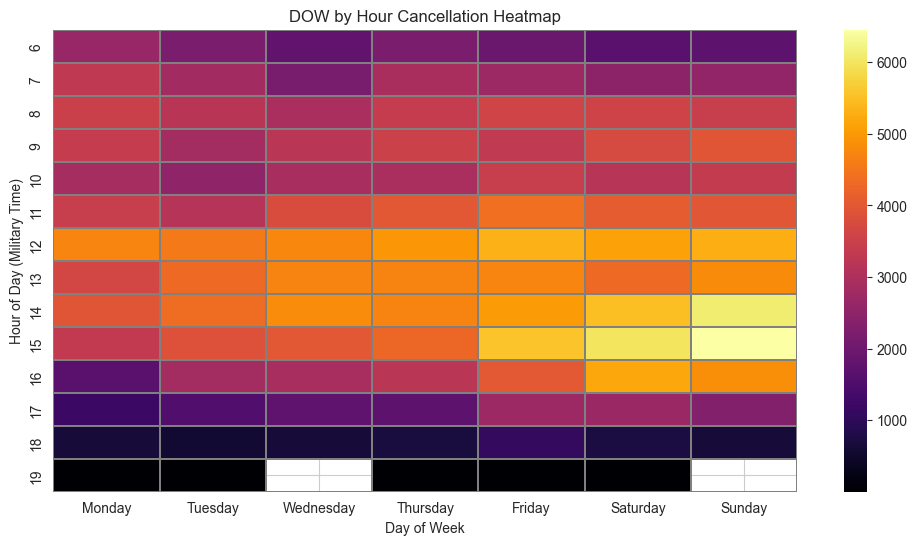

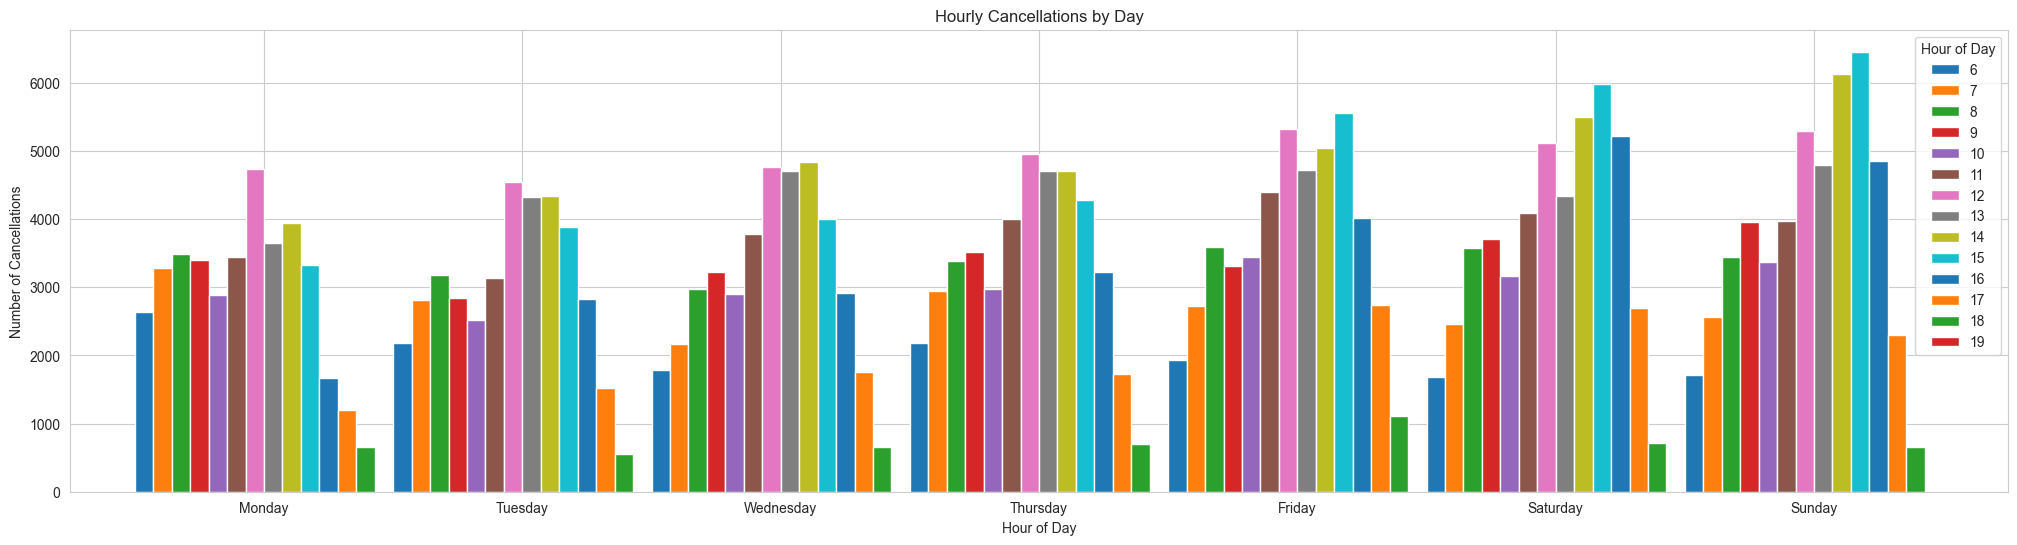

tee_time,1,2,3,4,5,6,7,8,9,10,11,12
tee_time,,,,,,,,,,,,
6,NaN,NaN,NaN,1005.0,4028.0,4065.0,3401.0,1422.0,209.0,NaN,NaN,NaN
7,NaN,NaN,275.0,4342.0,3173.0,2662.0,2365.0,3056.0,1867.0,963.0,231.0,8.0
8,NaN,NaN,1478.0,4601.0,2585.0,2112.0,2020.0,1712.0,2081.0,3426.0,3570.0,35.0
9,363.0,488.0,1519.0,3237.0,3260.0,2604.0,2669.0,2030.0,1637.0,1993.0,3700.0,435.0
10,974.0,1036.0,1196.0,2947.0,2310.0,2236.0,2262.0,1869.0,1882.0,1882.0,1798.0,850.0
11,827.0,754.0,1315.0,3699.0,3313.0,2818.0,2814.0,2440.0,2263.0,2557.0,3182.0,813.0
12,1228.0,1143.0,1661.0,4347.0,3982.0,3484.0,3541.0,3131.0,2915.0,3486.0,4309.0,1490.0
13,809.0,1368.0,1658.0,3498.0,3687.0,3254.0,3315.0,2770.0,2557.0,3713.0,3701.0,880.0
14,172.0,619.0,1632.0,4732.0,4378.0,4088.0,3825.0,3392.0,3776.0,5159.0,2423.0,273.0


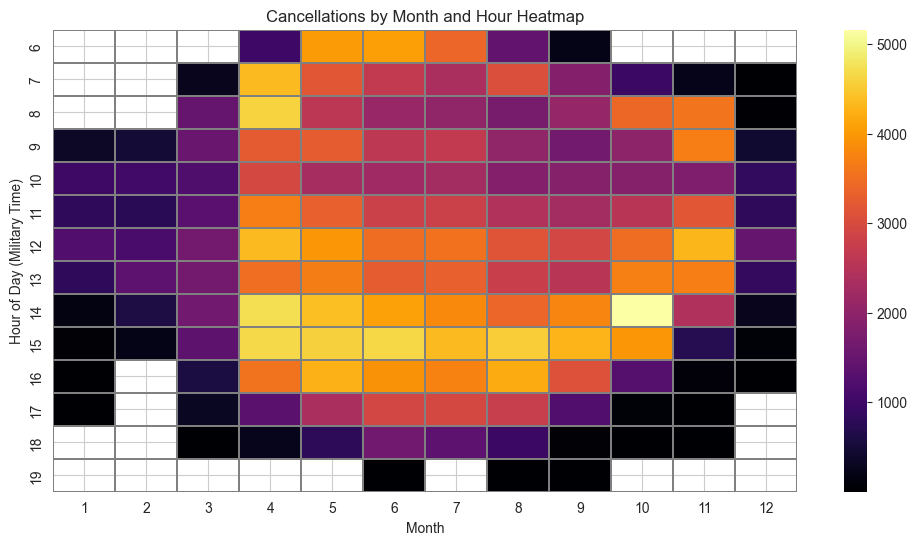

In [9]:
#plot matching graphs to examine which tee times are most commonly cancelled
df2_cancellation = df2[(df2["invalid_cancellation"] == False) & (df2["status_text"]=="cancelled")]

#cancellations by hour of day
hourly_cancellations = df2_cancellation.groupby(df2_cancellation["tee_time"].dt.hour).size()

hourly_cancellations.plot(kind="bar",figsize=(10,5))
plt.title("Cancellations by Hour")
plt.xlabel("Hour of Day (Military Time)")
plt.ylabel("Number of cancellations")
plt.show()

#cancellations by day of week 
DOW_cancellations = df2_cancellation.groupby(df2_cancellation["tee_time"].dt.day_name()).size()
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
DOW_cancellations = DOW_cancellations.reindex(day_order)

DOW_cancellations.plot(kind="bar",figsize=(10,5))
plt.title("Cancellations by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Cancellations")
plt.show()

#DOW vs Hour heatmap data
dow_cancel_heatmap_data = df2_cancellation.groupby([df2_cancellation["tee_time"].dt.hour,df2_cancellation["tee_time"].dt.dayofweek]).size().unstack()
dow_cancel_heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

#heatmap cancellations DOW
plt.figure(figsize=(12,6))
sns.heatmap(dow_cancel_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("DOW by Hour Cancellation Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#cancellations day by hour bar chart
dow_cancel_heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.0)
plt.title("Hourly Cancellations by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=0)
plt.show()

#cancellations by month and hour of day heatmap
monthly_cancellaions_heatmap_data = df2_cancellation.groupby([df2_cancellation["tee_time"].dt.hour,df2_cancellation['tee_time'].dt.month]).size().unstack()
display(monthly_cancellaions_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(monthly_cancellaions_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Cancellations by Month and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

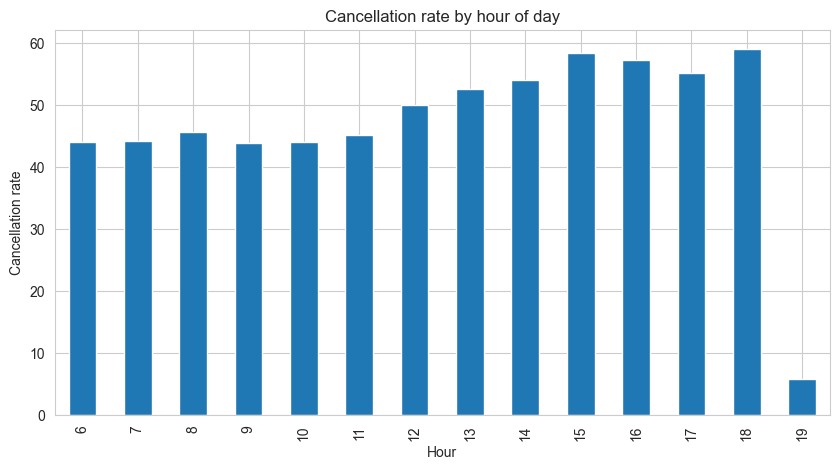

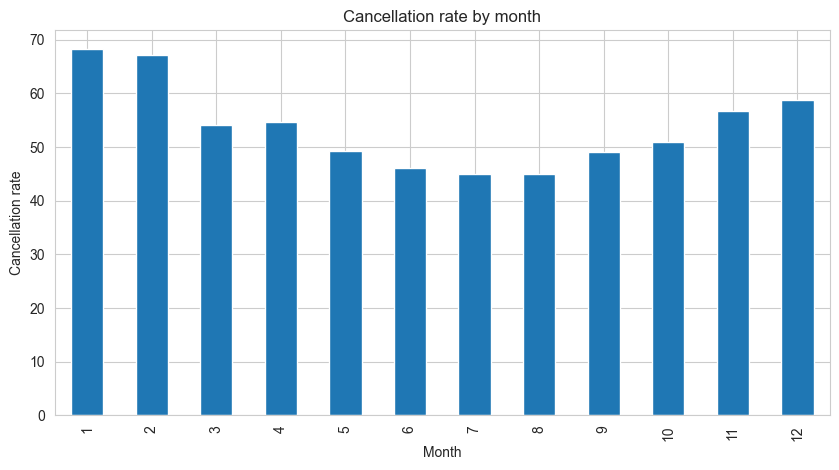

global cancallation rate: 0.5017289236171454


In [10]:
#check cancellation rate by month and hour to identify if it is non-constant
#hour
bookings_by_hour = df2.groupby(df2["tee_time"].dt.hour)["tee_time"].count()
cancellations_filtered = df2[((df2["status_text"] == "cancelled") & (df2["invalid_cancellation"] != True))].copy()
cancellations_by_hour = cancellations_filtered.groupby(cancellations_filtered["tee_time"].dt.hour)["tee_time"].count()
cancellation_rate_hour = round((cancellations_by_hour/bookings_by_hour)*100,2)
rate_hour_mean = cancellation_rate_hour.mean()

cancellation_rate_hour.plot(kind="bar",figsize=(10,5))
plt.title("Cancellation rate by hour of day")
plt.xlabel("Hour")
plt.ylabel("Cancellation rate")
plt.show()

#month
bookings_by_month = df2.groupby(df2["tee_time"].dt.month)["tee_time"].count()
cancellations_by_month = cancellations_filtered.groupby(cancellations_filtered["tee_time"].dt.month)["tee_time"].count()
cancellation_rate_month = round((cancellations_by_month/bookings_by_month)*100,2)
rate_month_mean = cancellation_rate_month.mean()

cancellation_rate_month.plot(kind="bar",figsize=(10,5))
plt.title("Cancellation rate by month")
plt.xlabel("Month")
plt.ylabel("Cancellation rate")
plt.show()

total_cancelled = (df2["status_text"] == "cancelled").sum()
total_bookings = len(df2)

overall_rate = total_cancelled / total_bookings
print(f"global cancallation rate: {overall_rate}")

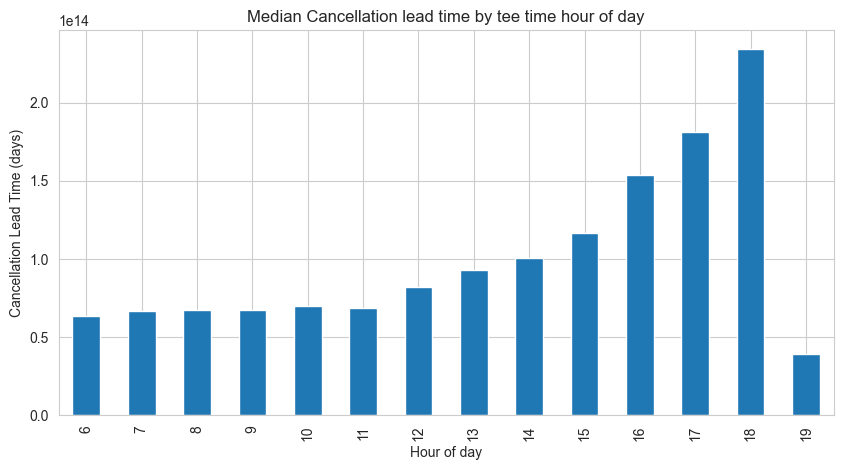

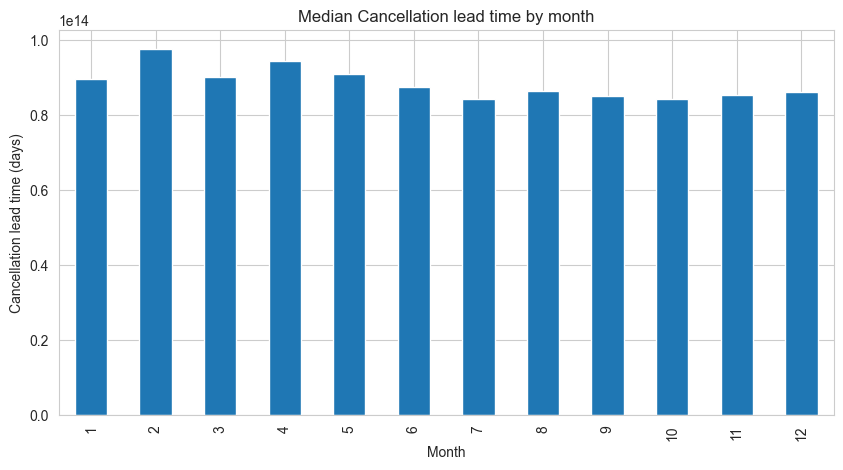

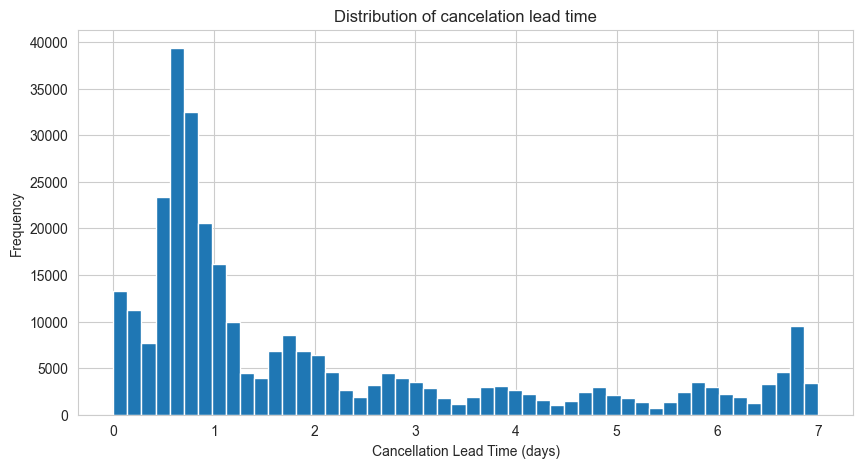

In [11]:
#add time before tee time metric to cancelled tee times
cancellations_filtered["cancellation_lead_time"] = cancellations_filtered["tee_time"]-cancellations_filtered["date_cancelled"]

cancellations_filtered["cancellation_lead_time"].describe()

#investigate illogcial lead times
negative_lt = cancellations_filtered[(cancellations_filtered["cancellation_lead_time"] < pd.Timedelta(0))]
# display(negative_lt)
long_lt = cancellations_filtered[(cancellations_filtered["cancellation_lead_time"] > pd.Timedelta(days=7))]
# display(long_lt)

#check cancellation lead time by month and hour to identify if it is non-constant
#hour
clt_by_hour = cancellations_filtered.groupby(df2["tee_time"].dt.hour)["cancellation_lead_time"].median()

clt_by_hour.plot(kind="bar",figsize=(10,5))
plt.title("Median Cancellation lead time by tee time hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Cancellation Lead Time (days)")
plt.show()

#month
clt_by_month = cancellations_filtered.groupby(df2["tee_time"].dt.month)["cancellation_lead_time"].median()

clt_by_month.plot(kind="bar",figsize=(10,5))
plt.title("Median Cancellation lead time by month")
plt.xlabel("Month")
plt.ylabel("Cancellation lead time (days)")
plt.show()

#histogram of cancellation lead time
hist_data_clt = cancellations_filtered[
    (cancellations_filtered["cancellation_lead_time"] >= pd.Timedelta(days=0)) &
    (cancellations_filtered["cancellation_lead_time"] <= pd.Timedelta(days=7))
]
(hist_data_clt["cancellation_lead_time"].dt.total_seconds()/ (60 * 60 * 24)).hist(bins=50, figsize=(10,5))
plt.title("Distribution of cancelation lead time")
plt.xlabel("Cancellation Lead Time (days)")
plt.ylabel("Frequency")
plt.show()

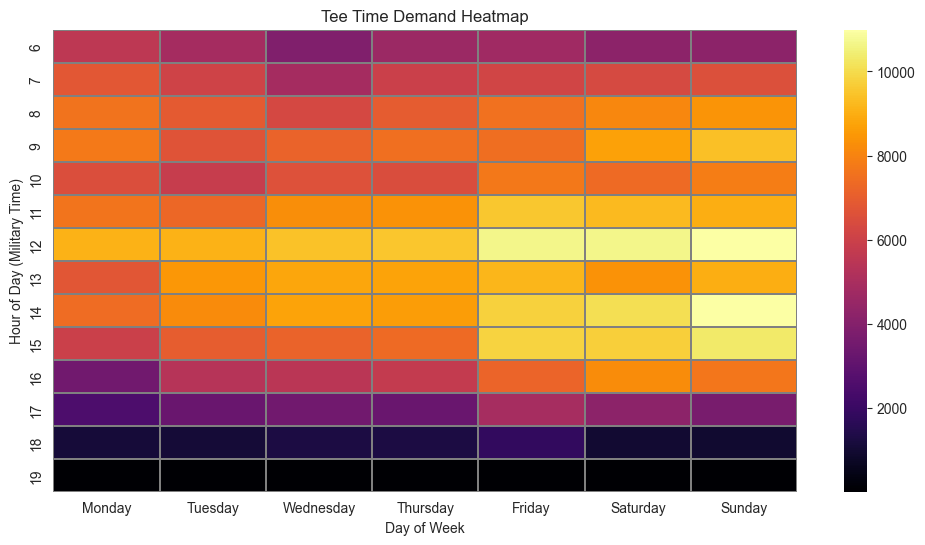

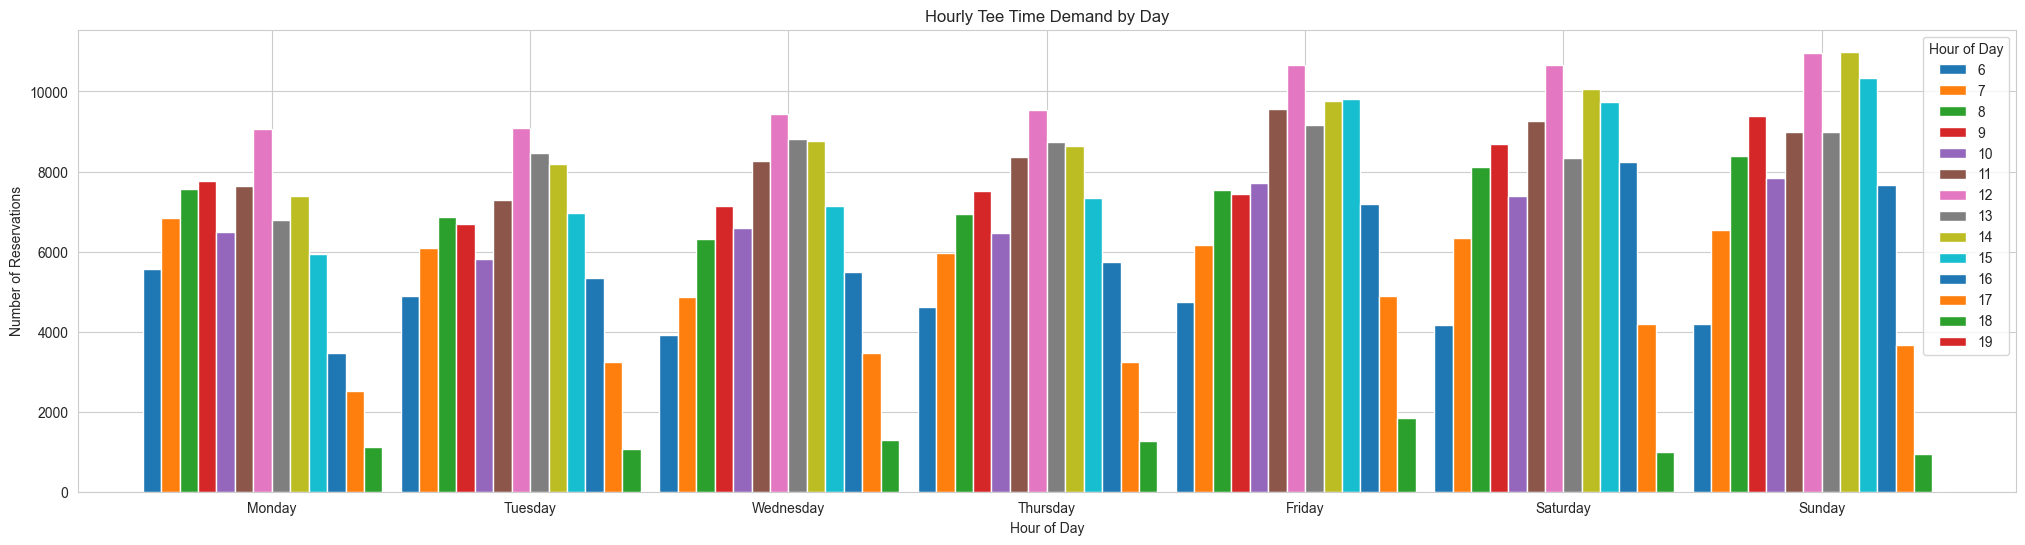

,Peak_Demand_Hour,Peak_Hr_2,Peak_Hr_3,Peak_Hr_4
Monday,12,9,11,8
Tuesday,12,13,14,11
Wednesday,12,13,14,11
Thursday,12,13,14,11
Friday,12,15,14,11
Saturday,12,14,15,11
Sunday,14,12,15,9


,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
24,2021-03-14 11:00:00,2021-03-07 19:02:00,played,NaT,weekend,midday,4,Blue,18,192.0,False,False
25,2021-03-14 11:09:00,2021-03-13 21:20:00,played,NaT,weekend,midday,1,Blue,18,48.0,False,False
26,2021-03-14 11:09:00,2021-03-14 05:36:00,played,NaT,weekend,midday,1,Blue,18,48.0,False,False
27,2021-03-14 11:09:00,2021-03-14 07:00:00,played,NaT,weekend,midday,1,Blue,18,48.0,False,False
28,2021-03-14 11:27:00,2021-03-14 00:06:00,played,NaT,weekend,midday,2,Yellow,9,96.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
616008,2025-10-21 13:42:00,2025-10-14 20:00:00,unknown,NaT,weekday,midday,1,Blue,18,15.0,False,False
616009,2025-10-21 13:42:00,2025-10-15 12:32:00,unknown,NaT,weekday,midday,1,Blue,18,23.0,False,False
616010,2025-10-21 13:51:00,2025-10-14 19:02:00,unknown,NaT,weekday,midday,4,Blue,18,92.0,False,False
616011,2025-10-21 14:00:00,2025-10-14 20:55:00,cancelled,2025-10-14 21:21:01,weekday,midday,4,Blue,18,NaN,False,False


Percent of bookings within 11am-3pm:309168
Cancellation stats:
Total bookings: 615701
Total cancellations: 306189
Overall cancellation rate: 49.73%



<Axes: title={'center': 'status_text distribution by year'}, xlabel='Year', ylabel='Count'>

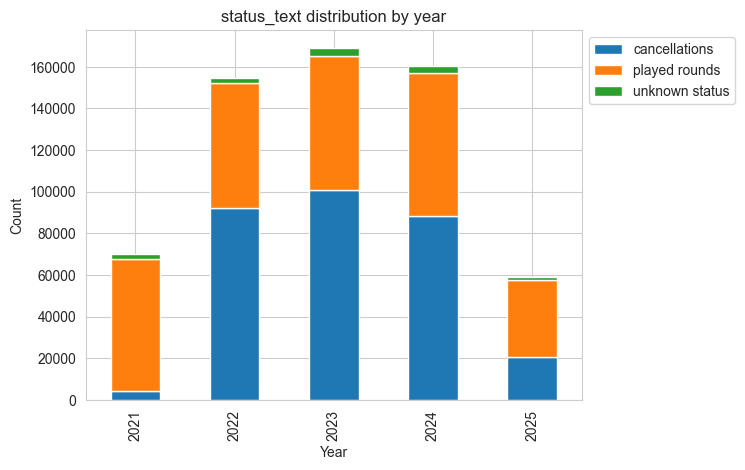

In [51]:
#Organized thoughts from initial EDA work

#phase 1 - System Baseline
##understand supply & demand distribution. Identify high demand / high value inventory

#demand by hour of day and day of week
#DOW vs Hour heatmap
demand_heatmap_data = df2.groupby([df["tee_time"].dt.hour,df["tee_time"].dt.dayofweek]).size().unstack()
demand_heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

#demand_heatmap
plt.figure(figsize=(12,6))
sns.heatmap(demand_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time Demand Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#day by hour bar chart
demand_heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.0)
plt.title("Hourly Tee Time Demand by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=0)
plt.show()

#peak demand time by DOW
peak_demand_data = demand_heatmap_data.copy()
demand_dist_table = pd.DataFrame(index=peak_demand_data.columns, columns=["Peak_Demand_Hour","Peak_Hr_2"
                                                                         ,"Peak_Hr_3","Peak_Hr_4"])
for col in peak_demand_data.columns:
    col_sort = peak_demand_data[col].copy().sort_values(ascending=False)
    demand_dist_table.loc[col] = col_sort.head(4).index

display(demand_dist_table)

high_demand_bookings = df2[(df2["tee_time"].dt.hour>=11)&(df2["tee_time"].dt.hour<16)]
display(high_demand_bookings)
print(f"Percent of bookings within 11am-3pm:{len(high_demand_bookings)}")
##Define "high value demand" as slots between 11am and 3pm (including bookings within )

#total cancellations
total_bookings = len(df2)
total_cancellations = len(df2_cancellation)
total_cancellation_rate = total_cancellations/total_bookings
print(f'''Cancellation stats:
Total bookings: {total_bookings}
Total cancellations: {total_cancellations}
Overall cancellation rate: {total_cancellation_rate:.2%}
''')

#Annual trend
valid_cancellations = df2.loc[~df2["invalid_cancellation"]]

rounds_by_year = valid_cancellations["tee_time"].groupby(valid_cancellations["tee_time"].dt.year).count().rename("rounds")

cancellations_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="cancelled"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("cancellations")

plays_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="played"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("played rounds")

unknown_by_year = valid_cancellations.loc[valid_cancellations["status_text"]=="unknown"].groupby(
    valid_cancellations["tee_time"].dt.year)["tee_time"].count().rename("unknown status")

status_text_dist = pd.concat([cancellations_by_year,plays_by_year,unknown_by_year],axis=1)

status_text_dist_graph = status_text_dist.plot.bar(stacked=True, title="status_text distribution by year")
status_text_dist_graph.set_xlabel('Year')
status_text_dist_graph.set_ylabel('Count')
fig = status_text_dist_graph.get_figure()
status_text_dist_graph.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1)
)
display(status_text_dist_graph)